# Part A: Define Your Multivariate Normal Distribution

The simulated population is defined using a three-variable multivariate normal distribution:

$$
X \sim N_3(\mu,\Sigma),
$$

where $X=(X_1,X_2,X_3)'$ represents the three variables in the server queuing system.

## A.1 Variables and Their Interpretation

The three variables are:

- $X_1$: represents customer arrival rate, in customers per hour.
- $X_2$: represents average service processing time, in minutes.
- $X_3$: represents queue length observed, in number of customers.

These three variables are appropriate for a queuing system because the number of customers arriving and the time required to serve them will influence how long the queue becomes.

---

## A.2 Mean Vector

Let us define the population mean vector as

$$
\mu =
\begin{bmatrix}
20 \\
15 \\
10
\end{bmatrix}
$$

Thus, the simulated population will have the following mean values.

$$
E(X_1)=20,
\qquad
E(X_2)=15,
\qquad
E(X_3)=10.
$$

This means that the average arrival rate is 20 customers per hour, the average service processing time is 15 minutes, and the average maximum queue length is 10 customers.

---

## A.3 Covariance Matrix

We set the standard deviations to be:

$$
\sigma_1 = 5,\qquad
\sigma_2 = 3,\qquad
\sigma_3 = 4,
$$

and the covariance matrix will be:

$$
\Sigma =
\begin{bmatrix}
25 & 3 & 15 \\
3 & 9 & 7.8 \\
15 & 7.8 & 16
\end{bmatrix}
$$

The diagonal elements represent the variance of the three variables:

$$
\sigma_1^2 = 25,\qquad
\sigma_2^2 = 9,\qquad
\sigma_3^2 = 16.
$$

This means that the corresponding standard deviation of the three variables are:

$$
\sigma_1=5,\qquad
\sigma_2=3,\qquad
\sigma_3=4.
$$

The off-diagonal elements represent the covariances between pairs of variables:

$$
\operatorname{Cov}(X_1,X_2)=3,
$$

$$
\operatorname{Cov}(X_1,X_3)=15,
$$

$$
\operatorname{Cov}(X_2,X_3)=7.8.
$$

Since these covariance values are positive, this means that the variables tend to increase together.

## A.4 Correlation Matrix

The corresponding correlation matrix is

$$
R =
\begin{bmatrix}
1.00 & 0.20 & 0.75 \\
0.20 & 1.00 & 0.65 \\
0.75 & 0.65 & 1.00
\end{bmatrix}
$$

This indicates that:

- $X_1$ and $X_2$ have a **weak positive correlation** of $0.20$.
- $X_1$ and $X_3$ have a **strong positive correlation** of $0.75$.
- $X_2$ and $X_3$ have a **moderately strong positive correlation** of $0.65$.

This means that the simulation assumes that higher customer arrival rates and longer service processing times will lead to longer maximum queue lengths.

---

## A.5 Appropriateness of the Covariance Matrix

The covariance matrix appropriate for this simulation due to the fact that it i symmetric because

$$
\Sigma_{ij} = \Sigma_{ji}.
$$

For example,

$$
\operatorname{Cov}(X_1,X_2)
=
\operatorname{Cov}(X_2,X_1)
=
3.
$$

It should also be noted that the diagonal elements are also positive as they represent the variances. The covariance values also produce positive correlation between the variables.

The proposed covariance structure is appropriate for a queuing system as it shows customer arrival rate and service time having a weak relationship with each other, while they both have a strong relationship with queue length. This is in line with the expected behavior of a queuing system: arrival rate and service time do not strongly impact each other, but they both have a strong affect on queue length.

Thus, it can be said that the chosen mean vector and covariance matrix are a reasonable multivariate model for the three variables.

In [7]:
# ==========================================
# PART A: Define Your Multivariate Normal Distribution
# ==========================================

import numpy as np

# Mean vector
mu = np.array([
    20,
    15,
    10
])

# Covariance matrix
sigma = np.array([
    [25, 3, 15],
    [3, 9, 7.8],
    [15, 7.8, 16]
])

# Calculating the correlation matrix
std = np.sqrt(np.diag(sigma))
R = sigma / np.outer(std, std)

print("Mean Vector (mu):")
print(mu)

print("\nCovariance Matrix (Sigma):")
print(sigma)

print("\nCorrelation Matrix (R):")
print(np.round(R, 2))

# Checking if Sigma is symmetric and positive definite

is_symmetric = np.allclose(sigma, sigma.T)
eigenvalues = np.linalg.eigvalsh(sigma)
is_positive_definite = np.all(eigenvalues > 0)

print("\nMatrix is symmetric:")
print(is_symmetric)
print("\nMatrix is positive definite (eigenvalues > 0):")
print(is_positive_definite)

Mean Vector (mu):
[20 15 10]

Covariance Matrix (Sigma):
[[25.   3.  15. ]
 [ 3.   9.   7.8]
 [15.   7.8 16. ]]

Correlation Matrix (R):
[[1.   0.2  0.75]
 [0.2  1.   0.65]
 [0.75 0.65 1.  ]]

Matrix is symmetric:
True

Matrix is positive definite (eigenvalues > 0):
True


# Part B: Generate and Explore the Simulated Data

In [8]:
# ==========================================
# PART B: Generating the large random sample
# ==========================================

import pandas as pd

np.random.seed(123)

# Sample size
n = 1000

# Generate multivariate normal observations
simulated_data = np.random.multivariate_normal(
    mean=mu,
    cov=sigma,
    size=n
)

# Convert into dataframe
df = pd.DataFrame(
    simulated_data,
    columns=[
        "Customer Arrival Rate (X1)",
        "Service Processing Time (X2)",
        "Maximum Queue Length (X3)"
    ]
)

# Display the first five observations
df.head()

,Customer Arrival Rate (X1),Service Processing Time (X2),Maximum Queue Length (X3)
0,26.654277,13.917300,13.139680
1,25.265506,17.482553,17.736759
2,30.003219,18.761054,20.653479
3,22.925063,18.057025,13.932207
4,12.142650,14.700125,4.791629


In [9]:
# ==========================================
# Descriptive Statistics
# ==========================================

# Simulated means
sim_means = df.mean()

# Simulated variances
sim_variances = df.var()

# Simulated covariance matrix
sim_covariance = df.cov()

# Simulated correlation matrix
sim_correlation = df.corr()

# Printing simulated values

print("Simulated Means:")
print(sim_means)

print("\nSimulated Variances:")
print(sim_variances)

print("Simulated Covariance Matrix:")
print(sim_covariance)

print("\nSimulated Correlation Matrix:")
print(sim_correlation.round(3))

Simulated Means:
Customer Arrival Rate (X1)      19.962999
Service Processing Time (X2)    15.041682
Maximum Queue Length (X3)       10.001995
dtype: float64

Simulated Variances:
Customer Arrival Rate (X1)      22.271714
Service Processing Time (X2)     9.320508
Maximum Queue Length (X3)       14.998812
dtype: float64
Simulated Covariance Matrix:
                              Customer Arrival Rate (X1)  \
Customer Arrival Rate (X1)                     22.271714   
Service Processing Time (X2)                    2.531737   
Maximum Queue Length (X3)                      13.430342   

                              Service Processing Time (X2)  \
Customer Arrival Rate (X1)                        2.531737   
Service Processing Time (X2)                      9.320508   
Maximum Queue Length (X3)                         7.692923   

                              Maximum Queue Length (X3)  
Customer Arrival Rate (X1)                    13.430342  
Service Processing Time (X2)                

In [16]:
# ==========================================
# Comparison Tables
# ==========================================

# Comparisonn of means

theoretical_means = pd.Series(
    mu,
    index=df.columns
)

mean_comparison = pd.DataFrame({
    "Theoretical Mean": theoretical_means,
    "Simulated Mean": sim_means
})

display(mean_comparison)

# Cmparison of Covariances

covariance_comparison = pd.DataFrame(
    sigma,
    index=df.columns,
    columns=df.columns
)

print("Theoretical Covariance Matrix:")
display(covariance_comparison)

print("Simulated Covariance Matrix:")
display(sim_covariance)

# Comparison of Correlation

theoretical_correlation = pd.DataFrame(
    R,
    index=df.columns,
    columns=df.columns
)

print("Theoretical Correlation Matrix:")
display(theoretical_correlation.round(3))

print("Simulated Correlation Matrix:")
display(sim_correlation.round(3))

,Theoretical Mean,Simulated Mean
Customer Arrival Rate (X1),20,19.962999
Service Processing Time (X2),15,15.041682
Maximum Queue Length (X3),10,10.001995


Theoretical Covariance Matrix:


,Customer Arrival Rate (X1),Service Processing Time (X2),Maximum Queue Length (X3)
Customer Arrival Rate (X1),25.0,3.0,15.0
Service Processing Time (X2),3.0,9.0,7.8
Maximum Queue Length (X3),15.0,7.8,16.0


Simulated Covariance Matrix:


,Customer Arrival Rate (X1),Service Processing Time (X2),Maximum Queue Length (X3)
Customer Arrival Rate (X1),22.271714,2.531737,13.430342
Service Processing Time (X2),2.531737,9.320508,7.692923
Maximum Queue Length (X3),13.430342,7.692923,14.998812


Theoretical Correlation Matrix:


,Customer Arrival Rate (X1),Service Processing Time (X2),Maximum Queue Length (X3)
Customer Arrival Rate (X1),1.00,0.20,0.75
Service Processing Time (X2),0.20,1.00,0.65
Maximum Queue Length (X3),0.75,0.65,1.00


Simulated Correlation Matrix:


,Customer Arrival Rate (X1),Service Processing Time (X2),Maximum Queue Length (X3)
Customer Arrival Rate (X1),1.000,0.176,0.735
Service Processing Time (X2),0.176,1.000,0.651
Maximum Queue Length (X3),0.735,0.651,1.000


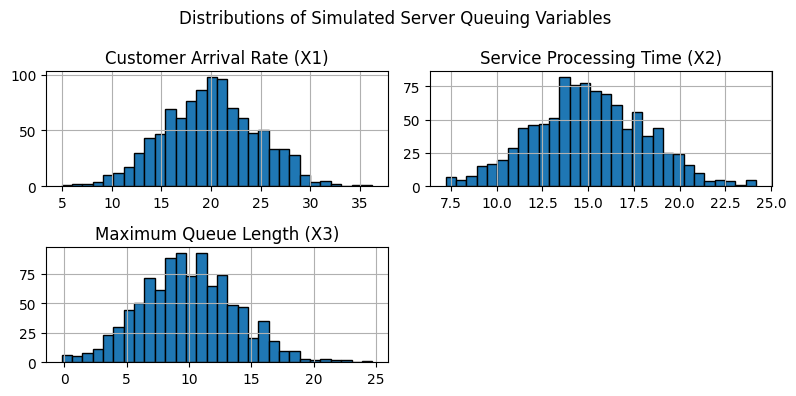

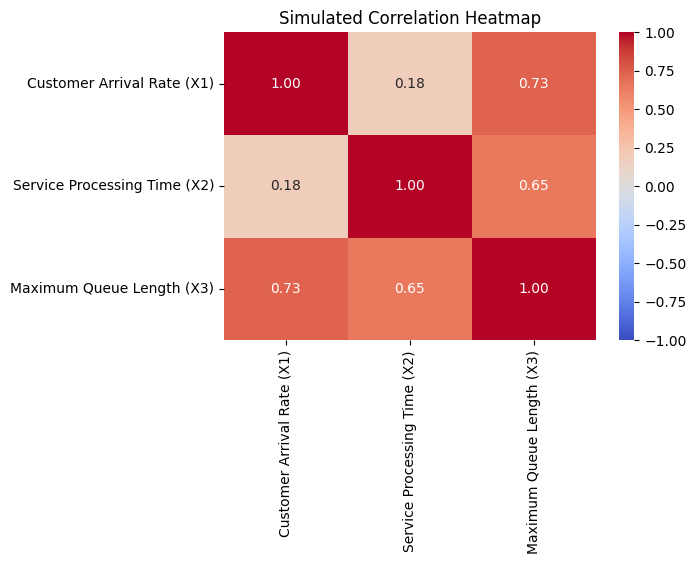

In [11]:
# ==========================================
# Visualization
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

# Histograms

df.hist(
    figsize=(8, 4),
    bins=30,
    edgecolor="black"
)

plt.suptitle(
    "Distributions of Simulated Server Queuing Variables"
)

plt.tight_layout()
plt.show()

# Correlation Heatmap

plt.figure(figsize=(6, 4))
sns.heatmap(sim_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Simulated Correlation Heatmap")
plt.show()

### Interpretation.

Discuss:
* whether the simulated means are close to the specified means:
The simulating means were reasonably close to the theoretical means. This small differences are to be expected since the observations were randomly simulated. N = 1000 observations were enough to keep the differences reasonably small

* whether the simulated variances are close to the specified variances:
Similar to the mean, the simulated variances were close to the theoretical values. Again, the differences were reasonably small and can be explained by the random generation.

* whether the simulated correlations reflect the specified correlations:
Once again, the simulated correlations managed to closely reflect the theoretical values. This means that the simulated correlarions managed to reflect the relationships which were specified in Part A: strong relationship between $X_1$ and $X_3$, moderate relationship between $X_2$ and $X_3$, and a weak relationship between $X_1$ and $X_2$.

* what the graphical displays reveal about the dependence among the variables:

The histogram showed that all three variables' distributions were centered around their mean, with $X_1$ being centered around 20, $X_2$ being centered around approximately 15 minutes, and $X_3$ being centered around approximately 10 customers.

Furthermore, the histograms for all three variables are generally bellshaped. This means that the normal distribution used to randomly generate the observations was successful. While there is some variation to be found in the center, there are no major unusual patterns.

Meanwhile, the correlation heatmap visualizes the numerical results. It shows that The relationship between $X_1$ and $X_3$ is relatively strong and positive, while the relationship between $X_2$ and $X_3$ is moderately strong and positive. The relationship between $X_1$ and $X_2$ is much weaker.

Overall, the visualizations were consistent with the theoretical values specified in Part A. The simulated data managed to show that higher arrival rates and longer service time leads to a larger queue. Thus the simulated data reproduced the means, variances, and correlation structure in Part A.

Part A and B's simulation generates $n=1000$ observations from the multivariate normal distribution,

$$
X\sim N_3(\boldsymbol{\mu},\boldsymbol{\Sigma}),
$$

with

$$
\boldsymbol{\mu}
=
\begin{bmatrix}
20\\
15\\
10
\end{bmatrix},
\qquad
\boldsymbol{\Sigma}
=
\begin{bmatrix}
25&3&15\\
3&9&7.8\\
15&7.8&16
\end{bmatrix}.
$$

The theoretical means were $20$, $15$, and $10$, while the simulated means were approximately $19.963$, $15.042$, and $10.002$, which are all very close to the specified values. The theoretical correlations,

$$
\rho_{12}=0.20,\qquad
\rho_{13}=0.75,\qquad
\rho_{23}=0.65,
$$

were also reasonably reproduced by the simulated values of $0.176$, $0.735$, and $0.651$. Most importantly, the simulation preserved the expected weak positive relationship between $X_1$ and $X_2$, strong positive relationship between $X_1$ and $X_3$, and moderately strong positive relationship between $X_2$ and $X_3$.

The small differences between theoretical and simulated values are to be expected because the data were randomly generated. With $n=1000$, the simulated statistics were reasonably close to the theoretical parameters, showing that the simulation followed the specified $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$.

# Part C: Investigate the Effect of Correlation

A bivariate normal simulation will be used to investigate the effect of correlation. This simulation will involve  two variables from the server queuing scenario specifically: Customer Arrival Rate ($X_1$) and Maximum Queue Length ($X_3$).

In order to see the effect of correlation, the other parameters will be kept constant. Thus, theoretical means ($\mu_1=20,\qquad \mu_3=10 $) and standard deviations ($\sigma_1=5,\qquad \sigma_3=4.
$) will remain.

Only the correlation coefficient $\rho$ will be changed. Three correlation settings will be compared:

$$
\rho=0.00,\qquad \rho=0.50,\qquad \rho=0.90.
$$

This will allow us to observe how increasing the correlation between Arrival Rate $X_1$ and Queue Length $X_3$ can change the shape and orientation of the simulated observations.

--

For each value of $\rho$, a sample of $n=1,000$ observations will be generated using a bivariate normal distribution.

The covariance between $X_1$ and $X_3$ is calculated using:

$$
\rho\sigma_1\sigma_3.
$$

Changing $\rho$ only changes the covariance between the two variables while their means and standard deviations are fixed.

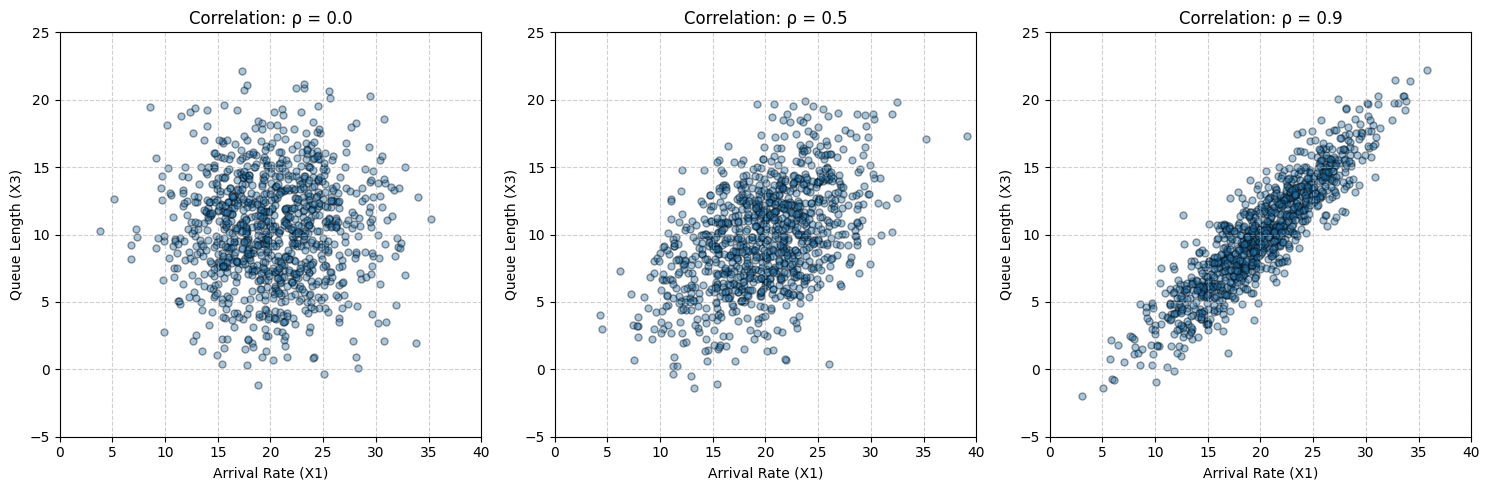

In [12]:
# Controlled parameters for Arrival Rate (X1) and Queue Length (X3)
mu_biv = np.array([20, 10])
sd_biv = np.array([5, 4])

# Generate multivariate samples
n = 1000
correlations = [0.00, 0.50, 0.90]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, rho in enumerate(correlations):

    # Calculate covariance from the selected correlation
    cov_13 = rho * sd_biv[0] * sd_biv[1]

    # Construct the covariance matrix
    sigma_biv = np.array([
        [sd_biv[0]**2, cov_13],
        [cov_13, sd_biv[1]**2]
    ])

    # Generate multivariate normal observations
    data = np.random.multivariate_normal(
        mu_biv,
        sigma_biv,
        n
    )

    # Scatterplot
    axes[i].scatter(
        data[:, 0],
        data[:, 1],
        alpha=0.4,
        edgecolor='k',
        s=25
    )

    axes[i].set_title(f"Correlation: ρ = {rho}")
    axes[i].set_xlabel("Arrival Rate (X1)")
    axes[i].set_ylabel("Queue Length (X3)")

    # Keep axes the same for comparison' sake
    axes[i].set_xlim(0, 40)
    axes[i].set_ylim(-5, 25)

    axes[i].grid(
        True,
        linestyle='--',
        alpha=0.6
    )

plt.tight_layout()
plt.show()

* Compare the shape and orientation of the simulated observations:

$\rho=0.00$

The points form a broad, circular cloud, because the simulated points have no direction.  This is because the correlation is zero, therefore two variables have no linear relationship.

$\rho=0.50$

A positive linear relationship is shown between the two variables. The simulated points now show a clearer upward orientation, causing the cloud to be less broad and more elongated. Higher values of $X_1$  are now generally associated with higher values of $X_3$ although it should be noted that there is still variation seen in the middle.

$\rho=0.90$

When the correlation is increased to $0.90$, the positive relationship seen in the previous plot becomes much stronger. The simulated points are now concentrated  tightly around an upward-sloping line, showing that observations with higher arrival rates tend to occur with higher queue lengths. Although there are still variations, it is now fewer.

* Explain how increasing or decreasing correlation affects the distribution:
Increasing the correlation, and keeping mans and standard deviations fixed resulted in distribution changing. The distribution went from a dispersed cloud into a narrow band. The orientation also starts to become a positive sloping line.

This is because correlation shows the strength and direction of the relationship between variables. A positive correlation means that high values of one variables usually happen with high values of the other variable. Thus, when correlation is closer to 1, $X_1$ tends to give more information about $X_3$. On the other handd, a correlation fo 0, means that $X_1$ gives no information about $X_3$.

Part C's simulation uses $X_1$ and $X_3$ with fixed means and standard deviations,

$$
\mu_1=20,\qquad \mu_3=10,
$$

$$
\sigma_1=5,\qquad \sigma_3=4,
$$

while changing the correlation to

$$
\rho=0,\quad 0.50,\quad 0.90.
$$

Theoretically, increasing the positive correlation between the two variables should make the observations more concentrated along an upward-sloping direction. The simulation successfully followed this pattern. When $\rho=0$, the observations had no clear linear direction and were instead broadly dispered. At $\rho=0.50$, a positive relationship became clearer however there were still variations, and at $\rho=0.90$, the observations were more tightly concentrated around an upward-sloping line.

Therefore, increasing correlation managed to strengthen the positive relationship between $X_1$ and $X_3$ while keeping their means and standard deviations the same.

# Part D: Investigate a Linear Combination

We choose the following linear combination of the three simulated variables:

$$
Y=X_1+2X_2-X_3
$$

The coefficient vector is

$$
a=
\begin{bmatrix}
1\\
2\\
-1
\end{bmatrix}.
$$

This combines the three variables into one value, $Y$.


Theoretical vs Simulated Results:


,Measure,Theoretical,Simulated
0,Mean,40.0,40.044367
1,Variance,27.8,27.047131


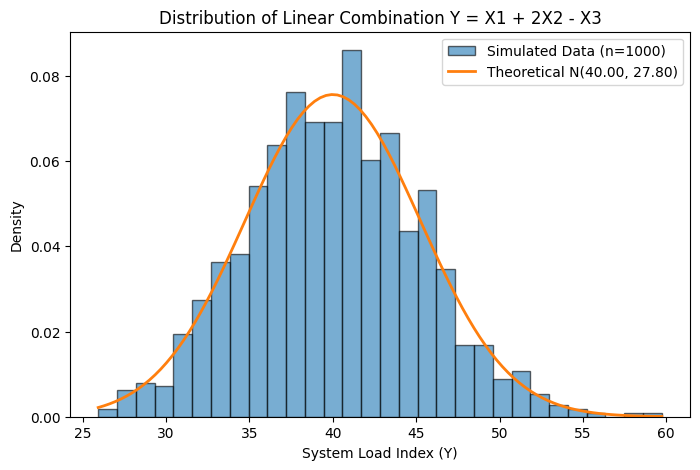

In [13]:
import scipy.stats as stats

# Parameters from Part A
mu = np.array([20, 15, 10])
sigma = np.array([
    [25, 3.0, 15.0],
    [3.0, 9.0, 7.8],
    [15.0, 7.8, 16.0]
])

# Generate n=1000 simulated observations
np.random.seed(123)
X_simulated = np.random.multivariate_normal(mu, sigma, 1000)

# 1. Define the coefficient vector 'a'
a = np.array([1, 2, -1])

# 2 & 3. Calculate theoretical mean and variance
theoretical_mean = a.T @ mu
theoretical_variance = a.T @ sigma @ a

def calculate_system_load(data: np.ndarray, coefficients: np.ndarray) -> np.ndarray:
    return data @ coefficients
Y_simulated = calculate_system_load(X_simulated, a)

sim_mean = np.mean(Y_simulated)
sim_variance = np.var(Y_simulated, ddof=1)  # ddof=1 for sample variance

# 5. Compare theoretical and simulated results

comparison = pd.DataFrame({
    "Measure": ["Mean", "Variance"],
    "Theoretical": [theoretical_mean, theoretical_variance],
    "Simulated": [sim_mean, sim_variance]
})

print("Theoretical vs Simulated Results:")
display(comparison)

# 6. Produce an appropriate graph
plt.figure(figsize=(8, 5))

# Histogram of simulated linear combination
plt.hist(
    Y_simulated,
    bins=30,
    density=True,
    alpha=0.6,
    edgecolor='black',
    label='Simulated Data (n=1000)'
)

# Theoretical normal distribution curve
x_axis = np.linspace(
    min(Y_simulated),
    max(Y_simulated),
    100
)

y_axis = stats.norm.pdf(
    x_axis,
    theoretical_mean,
    np.sqrt(theoretical_variance)
)

plt.plot(
    x_axis,
    y_axis,
    lw=2,
    label=f'Theoretical N({theoretical_mean:.2f}, {theoretical_variance:.2f})'
)

plt.title("Distribution of Linear Combination Y = X1 + 2X2 - X3")
plt.xlabel("System Load Index (Y)")
plt.ylabel("Density")
plt.legend()
plt.show()

**Does the Simulation Support the Theoretical Result?**

In the comparison table, it can be seen that the simulated mean and variance are close to the theoretical values of $40$ and $27.8$. FUrthermore, the histogram is also approximately bell-shaped, and it is similar to the theoretical normal curve. This confirms that the transformation retained its normality.

Therefore, it cane be said that the simulation supports the theoretical result:

$$
\boxed{
Y=a'X\sim N(a'\mu,a'\Sigma a)
}
$$

or, for this linear combination,

$$
\boxed{Y\sim N(40,19.8)}.
$$

Part D's simulation investigates the linear combination

$$
Y=X_1+2X_2-X_3.
$$

with theoretical mean and variance:

$$
E(Y)=40,
\qquad
\operatorname{Var}(Y)=27.8.
$$

The simulated results were:

$$
\bar{Y}=40.044,
\qquad
s_Y^2=27.047.
$$

The simulated values were close to the theoretical values, with the small differences being explained by the nature of random sampling. This supports the theoretical result that a linear combination of normally distributed variables is also normally distributed.

# Part E: Mahalanobis Distance and Chi-Square

<>:25: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:25: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1868/3466468435.py:25: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(x_axis, y_axis, color='darkred', lw=2, label='Theoretical $\chi^2_3$')
/tmp/ipykernel_1868/3466468435.py:30: SyntaxWarning: invalid escape sequence '\c'
  plt.title("Mahalanobis Distance ($D^2$) vs. $\chi^2_3$ Distribution")


90% Critical Value (chi^2_3):
6.2514
Proportion of observations inside 90% region:
0.919


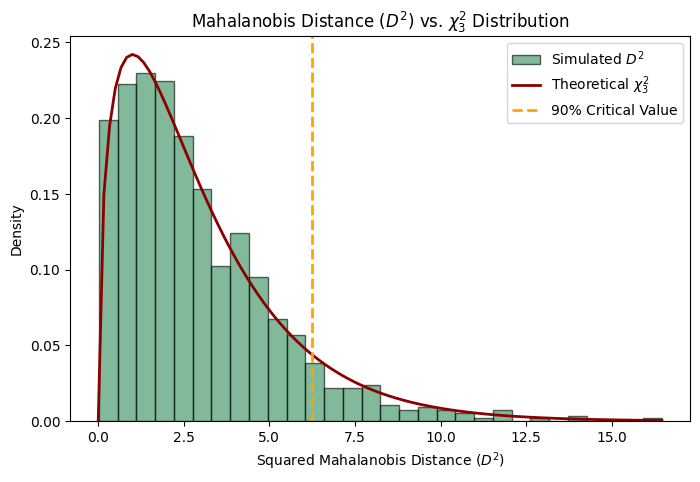

In [14]:
inv_sigma = np.linalg.inv(sigma)

# 1. Calculate D^2 for all simulated observations
diff = X_simulated - mu

D2 = np.sum(np.dot(diff, inv_sigma) * diff, axis=1)

# 4. Calculate proportion inside the 90% probability region
p = 3 # dof
chi2_90_percentile = stats.chi2.ppf(0.90, df=p)
proportion_inside = np.mean(D2 <= chi2_90_percentile)

print("90% Critical Value (chi^2_3):")
print(round(chi2_90_percentile, 4))
print("Proportion of observations inside 90% region:")
print(round(proportion_inside, 4))

# 2 & 3. Histogram and Comparison to Theoretical Distribution
plt.figure(figsize=(8, 5))
plt.hist(D2, bins=30, density=True, alpha=0.6, color='seagreen', edgecolor='black', label='Simulated $D^2$')

# Plot the theoretical chi-square distribution curve
x_axis = np.linspace(0, np.max(D2), 100)
y_axis = stats.chi2.pdf(x_axis, df=p)
plt.plot(x_axis, y_axis, color='darkred', lw=2, label='Theoretical $\chi^2_3$')

# Highlight the 90% probability region
plt.axvline(chi2_90_percentile, color='orange', linestyle='dashed', linewidth=2, label='90% Critical Value')

plt.title("Mahalanobis Distance ($D^2$) vs. $\chi^2_3$ Distribution")
plt.xlabel("Squared Mahalanobis Distance ($D^2$)")
plt.ylabel("Density")
plt.legend()
plt.show()

*  A brief interpretation of what the Mahalanobis distance represents:

The Mahalanobis distance ($D^2$) measures how far an observation is from the multivariate mean while still accounting for the variance and covariance among the variables. For this specific simulation, $D^2$ measures how far an observation is from the average behaviot of the queuing system, while still taking in consideration the three variables together: arrival rate ($X_1$), service time ($X_2$), and queue length ($X_3$). This also accounts for the correlations between the three variables.

For our data, the Mahalanobis distance is calculated as

$$
D^2=(\mathbf{x}-\boldsymbol{\mu})^T
\boldsymbol{\Sigma}^{-1}
(\mathbf{x}-\boldsymbol{\mu})
$$

A small $D^2$ means that the observation is in line with the usual pattern of the queuing system. For example, an observation with a low arrival rate and a short queue length will likely have a small $D^2$ because these variables are positively correlated, making this combination likely in the data.

Meanwhile, a large $D^2$ means that the observation strays from the usual pattern of the system. For example, a low customer arrival rate but an unusually long queue length would result in a larger $D^2$, because this combination is unexpected based on the relationships found in the data.

In the simulation, the \textbf{90% critical value} is

$$
\chi^2_3(0.90)=6.2514
$$

Approximately

$$
91.9\%
$$

of the observations have $D^2$ values below this critical value. This indicates that majority of the simulated observations followed the expected pattern of the queuing system, while observations with

$$
D^2 > 6.2514
$$

can be considered unusually far from the normal operating pattern.


Part E's simulation calculates the Mahalanobis distance, which measures how far an observation is from the multivariate mean while still accounting for the covariance structure. Since there are three variables,

$$
D^2\sim\chi_3^2.
$$

The theoretical 90\% critical value was

$$
\chi_3^2(0.90)=6.2514.
$$

The simulation found that $91.9\%$ of observations had $D^2$ values below this valuem which is close to the expected $90\%$, with the difference being attributed to the sampling variation. Therefore, it can be said that most observations were consistent with the expected multivariate distribution, while observations with

$$
D^2>6.2514
$$

were relatively far from the multivariate mean.

# Custom Investigation

---

## Option B: Subset of Variables

The subset of the simulated variables will contain customer arrival rate ($X_1$) and service time ($X_2$).

Since it was shown that the original variables follow a multivariate normal distribution, we know that any subset of the variables is also normally distributed.

The corresponding means and covariance values are taken from the original $\mu$ and $\Sigma$:

$$
\mu_{\text{sub}}=
\begin{bmatrix}
20\
15
\end{bmatrix}
$$

and

$$
\Sigma_{\text{sub}}=
\begin{bmatrix}
25&3\
3&9
\end{bmatrix}.
$$

Thus, the theoretical distribution is

$$
\boxed{
X_{\text{sub}}\sim N_2
\left(
\begin{bmatrix}
20\
15
\end{bmatrix},
\begin{bmatrix}
25&3\
3&9
\end{bmatrix}
\right)
}.
$$

Theoretical Mean:
[20, 15]

Simulated Mean:
[19.96299879 15.04168157]

Theoretical Covariance:
[[25, 3], [3, 9]]

Simulated Covariance:
[[22.27171392  2.53173688]
 [ 2.53173688  9.32050792]]


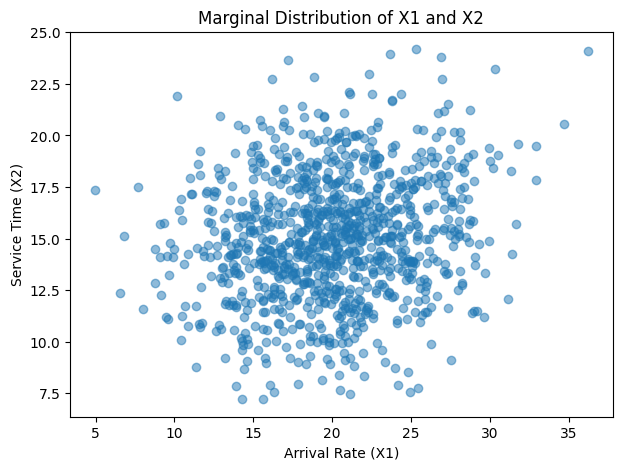

In [15]:
# Select X1 and X2
subset_data = X_simulated[:, 0:2]

# Calculate simulated mean and covariance
simulated_mean = np.mean(subset_data, axis=0)
simulated_covariance = np.cov(subset_data, rowvar=False)

print("Theoretical Mean:")
print([20, 15])

print("\nSimulated Mean:")
print(simulated_mean)

print("\nTheoretical Covariance:")
print([[25, 3], [3, 9]])

print("\nSimulated Covariance:")
print(simulated_covariance)

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(subset_data[:, 0], subset_data[:, 1], alpha=0.5)

plt.title("Marginal Distribution of X1 and X2")
plt.xlabel("Arrival Rate (X1)")
plt.ylabel("Service Time (X2)")
plt.show()

As shown, the simulated means and covariance are in line with the theoretical values. The values are reasonably close enough, and the difference is a standard occurence in sampling variability due to the random see.

In the grpah, it can be seen that there is good portion of the points centered around (20,15) which are the subset means. It can also be seen that both of the axis is in line with their given standard deviations. Lastly, the shape and orientation of the plot managed to show the weak positive correlation of $X_1$ and $X_2$.

Therefore this simulation confirms that the distribution of a subset of a multivariate normal distribution is also normally distributed, with its mean vector and covariance matrix taken from the original values.

This simulation examines the the subset $X_1$ and $X_2$.. The theoretical distribution was

$$
X_{\text{sub}}
\sim
N_2
\left(
\begin{bmatrix}
20\\
15
\end{bmatrix},
\begin{bmatrix}
25&3\\
3&9
\end{bmatrix}
\right).
$$

The simulated means were approximately $(19.963,\;15.042)$, which were close to the theoretical values $(20,15)$. Also, it can be seen that the simulated covariance matrix was close to the theoretical covariance matrix, and the scatterplot managed to successfully show the expected weak positive relationship between $X_1$ and $X_2$.

Again, the small differences are to be expected because of random sampling. Overall, the results support the theoretical result that a subset of a multivariate normal distribution is also normally distributed, as long as its corresponding mean vector and covariance matrix were obtained from the original distribution.

# Conclusion

This activity used a three-variable multivariate normal distribution: $X \sim N_3(\mu,\Sigma) $where $X=(X_1,X_2,X_3)'$ represents the three variables in the server queuing system. Specifically, $X_1$ represents customer arrival rate in customers per hour, $X_2$ represent service time in minutes, and $X_3$ represent length of the queue.

As a collective the simulations were able to successfully show the properties of a multivariate normal distribution. The means, variances, covariances, and correlations obtained from the simulation were reasonably close to the specified theoretical values. The small differences between the simulated and tehoretical values are to be expected since the observations were randomly generated.

In addition, the correlation experiment between the variables $X_1$ and $X_3$, performed in Task C were able to demonstrate how chnaging the correlation changes the strength and oreintation of the relationship between variables. The generated graphs showed that as correlation went from $0.00$ to $0.50$ to $0.90$, the points start to become more tightly packed and start to follow a diagonal pattern, indicating that the relationship between customer arrival rate and queue length became stronger and more clearly positive.

Task D's linear combination simulation and graph supported the theoretical result that a linear combination of multivariate normal variables is also normally distributed. The Mahalanobis distance results in Task E were also in line with the expected \(\chi^2_3\) behavior, with \(91.9\%\) of observations falling inside the theoretical 90% region. Lastly, the subset simulation showed that selected variables from a multivariate normal distribution retain a multivariate normal distribution with the use of the same mean and covariance values.

Overall, it can be said that the simulation results were aligned with the properties of the theoretical values of the multivariate normal distribution  Further, it showed how the mean, variance, covariance, correlation, and multivariate structure impacts the simulated data.
